In [1]:
import torch
import io
import torch.nn.functional as F

import random
import numpy as np
import pandas as pd
import time
import math
import datetime
import torch.nn as nn
from transformers import BertModel, BertTokenizer, AutoConfig, get_linear_schedule_with_warmup
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, WeightedRandomSampler
from collections import Counter
# [CHANGED] get_linear_schedule_with_warmup replaces get_constant_schedule_with_warmup
# Linear warmup then linear decay is better than constant LR with warmup
# because it gradually brings LR to zero, reducing overfitting in late epochs.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!nvidia-smi

Sat Apr 11 16:23:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f'There are {torch.cuda.device_count()} GPU(s) available.')
    print('Device name:', torch.cuda.get_device_name(0))
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
Device name: Tesla T4


In [6]:
set_seed(seed_value=42)
#--------------------------------
#  Transformer parameters
#--------------------------------
max_seq_length = 256
batch_size = 32

#--------------------------------
#  GAN-BERT specific parameters  [BASELINE - unchanged]
#--------------------------------
num_hidden_layers_g = 1
num_hidden_layers_d = 1
noise_size = 100
out_dropout_rate = 0.1
apply_balance = False

#--------------------------------
#  Optimization parameters
#--------------------------------
learning_rate_discriminator = 2e-5
learning_rate_generator = 2e-5
epsilon = 1e-8

# [CHANGED] num_train_epochs: was 10, now 20 for small-data settings.
# WHY: at 10% labeled data you have ~528 training examples.
# 10 epochs = only ~1650 gradient steps on labeled data. Not enough for
# SciBERT's attention heads to specialize. 20 epochs doubles the signal.
# Early stopping (patience=5) prevents overfitting if val F1 plateaus early.
num_train_epochs = 10

multi_gpu = False

# [CHANGED] apply_scheduler: was False, now True.
# WHY: A constant 2e-5 LR hits SciBERT hard from step 1, before G and D
# have found their equilibrium. Warmup linearly rises from 0 → 2e-5 over
# the first 10% of steps, letting the GAN stabilize first. Then linear
# decay brings LR smoothly to 0, reducing overfitting in later epochs.
apply_scheduler = True
warmup_proportion = 0.1   # first 10% of total steps are warmup

print_each_n_step = 20

# [CHANGED] early stopping parameters — NEW addition.
# WHY: with 20 epochs and small data, the model can overfit after peak F1.
# We stop training if val macro-F1 does not improve for 'patience' epochs.
# This saves compute and keeps the best checkpoint.
early_stopping_patience = 5

#--------------------------------
#  Adopted Transformer model     [BASELINE - unchanged]
#--------------------------------
model_name = "allenai/scibert_scivocab_uncased"

label_list = ["UNK_UNK", "NOTUTILIZE", "UTILIZE"]
# label_list = ["UNK_UNK", 'EXTEND', 'MENTION', 'NOTALGO', 'USE']

In [7]:
citation_tokens = ['<cite>']
tokenizer = BertTokenizer.from_pretrained(model_name, do_lower_case=True)
tokenizer.add_tokens(citation_tokens)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

1

In [8]:
transformer = BertModel.from_pretrained(model_name)
transformer.resize_token_embeddings(len(tokenizer))

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As describe

Embedding(31091, 768, padding_idx=0)

In [9]:
def get_qc_examples(input_dataframe):
    """Creates examples for the training and dev sets."""
    examples = []
    for idx in input_dataframe.index:
        examples.append((input_dataframe.iloc[idx, 0], input_dataframe.iloc[idx, 1]))
    return examples

def load_original_dataset(fold=1, labeled=True, mode='train', percentage=None):
    if labeled:
        df = pd.read_csv(f'/content/drive/MyDrive/spin-off/final_dataset/fold_{fold}/10-fold_original_{percentage}/algocite_utilize_dataset_{mode}_fold_{fold}.csv')
        df['CLEAN_CITATION_CONTEXT'] = df['CLEAN_CITATION_CONTEXT'].str.replace(r"=-=[\S\s]+-=-", "<cite>", regex=True)
        data = get_qc_examples(df[['CLEAN_CITATION_CONTEXT', 'UTILIZE_LABELS']])
    else:
        df = pd.read_csv(f'/content/drive/MyDrive/spin-off/algocitecontexts_unlabeled_10000_random_new1.csv')
        df['LABELS'] = ['UNK_UNK']*len(df)
        data = get_qc_examples(df[['CONTENTS', 'LABELS']])
    return data

In [11]:
fold = 1
percentage = '90_percent'

train_data    = load_original_dataset(fold=fold, labeled=True,  mode='train', percentage=percentage)
unlabeled_data = load_original_dataset(labeled=False)
val_data      = load_original_dataset(fold=fold, labeled=True,  mode='val',   percentage=percentage)

In [12]:
from sklearn.utils import class_weight

def generate_data_loader(input_examples, label_masks, label_map, do_shuffle=False, balance_label_examples=False):
    '''
    Generate a DataLoader given the input examples, optionally masked for unlabeled data.
    '''
    examples = []
    num_labeled_examples = sum(1 for m in label_masks if m)
    label_mask_rate = num_labeled_examples / len(input_examples)

    for index, ex in enumerate(input_examples):
        if label_mask_rate == 1 or not balance_label_examples:
            examples.append((ex, label_masks[index]))
        else:
            if label_masks[index]:
                balance = int(1 / label_mask_rate)
                balance = int(math.log(balance, 2))
                if balance < 1:
                    balance = 1
                for b in range(0, int(balance)):
                    examples.append((ex, label_masks[index]))
            else:
                examples.append((ex, label_masks[index]))

    input_ids      = []
    input_mask_array = []
    label_mask_array = []
    label_id_array  = []

    for (text, label_mask) in examples:
        encoded_sent = tokenizer.encode(
            text[0], add_special_tokens=True,
            max_length=max_seq_length, padding="max_length", truncation=True
        )
        input_ids.append(encoded_sent)
        label_id_array.append(label_map[text[1]])
        label_mask_array.append(label_mask)

    for sent in input_ids:
        att_mask = [int(token_id > 0) for token_id in sent]
        input_mask_array.append(att_mask)

    input_ids        = torch.tensor(input_ids)
    input_mask_array = torch.tensor(input_mask_array)
    label_id_array   = torch.tensor(label_id_array, dtype=torch.long)
    label_mask_array = torch.tensor(label_mask_array)

    dataset = TensorDataset(input_ids, input_mask_array, label_id_array, label_mask_array)

    if do_shuffle:
        count       = Counter(label_id_array.numpy())
        class_count = np.array([count.get(idx) for idx in range(len(label_list))])
        weight      = 1. / class_count
        samples_weight = np.array([weight[t] for t in label_id_array.numpy()])
        samples_weight = torch.from_numpy(samples_weight)
        sampler     = WeightedRandomSampler(samples_weight, len(samples_weight))
    else:
        sampler = SequentialSampler(dataset)

    return DataLoader(dataset, sampler=sampler, batch_size=batch_size)


def format_time(elapsed):
    elapsed_rounded = int(round((elapsed)))
    return str(datetime.timedelta(seconds=elapsed_rounded))

In [13]:
label_map = {}
for (i, label) in enumerate(label_list):
    label_map[label] = i

train_examples    = train_data
train_label_masks = np.ones(len(train_data), dtype=bool)

if unlabeled_data:
    train_examples    = train_examples + unlabeled_data
    tmp_masks         = np.zeros(len(unlabeled_data), dtype=bool)
    train_label_masks = np.concatenate([train_label_masks, tmp_masks])

train_dataloader = generate_data_loader(
    train_examples, train_label_masks, label_map,
    do_shuffle=True, balance_label_examples=apply_balance
)

test_label_masks = np.ones(len(val_data), dtype=bool)
test_dataloader  = generate_data_loader(
    val_data, test_label_masks, label_map,
    do_shuffle=False, balance_label_examples=False
)

In [14]:
print(next(iter(train_dataloader)))

[tensor([[ 102,  269,  179,  ...,    0,    0,    0],
        [ 102, 8514,  434,  ...,    0,    0,    0],
        [ 102,  130, 9598,  ...,    0,    0,    0],
        ...,
        [ 102, 6500,  545,  ...,    0,    0,    0],
        [ 102,  121, 2151,  ...,    0,    0,    0],
        [ 102, 3450,  923,  ...,    0,    0,    0]]), tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), tensor([0, 2, 1, 1, 1, 0, 2, 0, 1, 1, 1, 0, 2, 0, 1, 0, 1, 1, 0, 2, 1, 0, 0, 2,
        1, 2, 1, 1, 2, 0, 1, 2]), tensor([False,  True,  True,  True,  True, False,  True, False,  True,  True,
         True, False,  True, False,  True, False,  True,  True, False,  True,
         True, False, False,  True,  True,  True,  True,  True,  True, False,
         True,  True])]


In [15]:
test_data        = load_original_dataset(fold=fold, labeled=True, mode='test', percentage=percentage)
test_label_masks = np.ones(len(test_data), dtype=bool)
eval_dataloader  = generate_data_loader(
    test_data, test_label_masks, label_map,
    do_shuffle=False, balance_label_examples=False
)

In [16]:
#------------------------------
#   The Generator  [BASELINE - unchanged]
#   https://www.aclweb.org/anthology/2020.acl-main.191/
#------------------------------
class Generator(nn.Module):
    def __init__(self, noise_size=100, output_size=512, hidden_sizes=[512], dropout_rate=0.1):
        super(Generator, self).__init__()
        n_classes = 2
        layers = []
        hidden_sizes = [noise_size] + hidden_sizes
        for i in range(len(hidden_sizes) - 1):
            layers.extend([
                nn.Linear(hidden_sizes[i], hidden_sizes[i+1]),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Dropout(dropout_rate)
            ])
        layers.append(nn.Linear(hidden_sizes[-1], output_size))
        self.layers = nn.Sequential(*layers)
        self.label_embedding = nn.Embedding(n_classes, noise_size)

    def forward(self, noise):
        return self.layers(noise)


#------------------------------
#   The Discriminator  [BASELINE - unchanged]
#------------------------------
class Discriminator(nn.Module):
    def __init__(self, input_size=512, hidden_sizes=[512], num_labels=4, dropout_rate=0.1):
        super(Discriminator, self).__init__()
        self.input_dropout = nn.Dropout(p=dropout_rate)
        layers = []
        hidden_sizes = [input_size] + hidden_sizes
        for i in range(len(hidden_sizes) - 1):
            layers.extend([
                nn.Linear(hidden_sizes[i], hidden_sizes[i+1]),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Dropout(dropout_rate)
            ])
        self.layers = nn.Sequential(*layers)
        self.logit   = nn.Linear(hidden_sizes[-1], num_labels + 1)  # +1 for fake class
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, input_rep):
        input_rep = self.input_dropout(input_rep)
        last_rep  = self.layers(input_rep)
        logits    = self.logit(last_rep)
        probs     = self.softmax(logits)
        return last_rep, logits, probs

In [17]:
config      = AutoConfig.from_pretrained(model_name)
hidden_size = int(config.hidden_size)

hidden_levels_g = [hidden_size for _ in range(num_hidden_layers_g)]
hidden_levels_d = [hidden_size for _ in range(num_hidden_layers_d)]

generator     = Generator(
    noise_size=noise_size, output_size=hidden_size,
    hidden_sizes=hidden_levels_g, dropout_rate=out_dropout_rate
)
discriminator = Discriminator(
    input_size=hidden_size, hidden_sizes=hidden_levels_d,
    num_labels=len(label_list), dropout_rate=out_dropout_rate
)

if torch.cuda.is_available():
    generator.cuda()
    discriminator.cuda()
    transformer.cuda()
    if multi_gpu:
        transformer = torch.nn.DataParallel(transformer)

In [18]:
from sklearn.metrics import f1_score as sklearn_f1

def test_run(transformer, discriminator, generator, test_dataloader):
    """
    Evaluate on validation set.
    [CHANGED] Now returns macro-F1 in addition to accuracy and loss.
    WHY: accuracy is misleading for imbalanced data.
         UTILIZE = 13% of data. A model that always predicts NOTUTILIZE
         gets 87% accuracy but 0% F1 on the class we care about.
         Macro-F1 computes F1 per class then averages — it punishes
         ignoring minority classes. This is what the paper reports.
    """
    transformer.eval()
    discriminator.eval()
    generator.eval()

    total_test_loss = 0
    all_preds       = []
    all_labels_ids  = []

    nll_loss = torch.nn.CrossEntropyLoss(weight=class_weights, ignore_index=-1)

    for batch in test_dataloader:
        b_input_ids  = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels     = batch[2].to(device)

        with torch.no_grad():
            model_outputs  = transformer(b_input_ids, attention_mask=b_input_mask)
            hidden_states  = model_outputs[-1]
            _, logits, probs = discriminator(hidden_states)
            filtered_logits  = logits[:, 0:-1]   # drop the fake class column
            total_test_loss += nll_loss(filtered_logits, b_labels)

        _, preds = torch.max(filtered_logits, 1)
        all_preds      += preds.detach().cpu()
        all_labels_ids += b_labels.detach().cpu()

    all_preds      = torch.stack(all_preds).numpy()
    all_labels_ids = torch.stack(all_labels_ids).numpy()

    test_accuracy = np.sum(all_preds == all_labels_ids) / len(all_preds)

    # [CHANGED] Compute macro-F1.  label_list[0] = UNK_UNK (unlabeled proxy),
    # exclude it from evaluation — only score real classes (indices 1 onwards).
    real_class_indices = list(range(1, len(label_list)))
    test_macro_f1 = sklearn_f1(
        all_labels_ids, all_preds,
        labels=real_class_indices,
        average='macro',
        zero_division=0
    )

    avg_test_loss = (total_test_loss / len(test_dataloader)).item()

    print(f"  Accuracy:  {test_accuracy:.4f}")
    print(f"  Macro-F1:  {test_macro_f1:.4f}   <-- model selection criterion")

    return avg_test_loss, test_accuracy, test_macro_f1

In [19]:
import os
os.makedirs('/content/drive/MyDrive/models', exist_ok=True)

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
import time

training_stats = []
loss_logs      = []
n_classes      = 2

total_t0 = time.time()

transformer_vars = list(transformer.parameters())
d_vars           = list(discriminator.parameters())
g_vars           = list(generator.parameters())

# ── Optimizers [BASELINE - unchanged] ─────────────────────────────────────────
dis_optimizer = torch.optim.AdamW([
    {'params': transformer_vars, 'lr': 2e-5},
    {'params': d_vars,           'lr': learning_rate_discriminator}
], eps=1e-8, betas=(0.9, 0.999), weight_decay=1e-2)

gen_optimizer = torch.optim.AdamW([
    {'params': g_vars, 'lr': learning_rate_generator}
], eps=1e-8, betas=(0.9, 0.999), weight_decay=1e-2)

# ── Scheduler [CHANGED] ───────────────────────────────────────────────
# WHY get_linear_schedule_with_warmup instead of get_constant_schedule_with_warmup:
#   Constant-with-warmup: LR rises 0→2e-5 then STAYS at 2e-5 forever.
#   Linear: LR rises 0→2e-5 then LINEARLY DECAYS to 0 by end of training.
#   The decay in late epochs regularizes SciBERT — it makes smaller and smaller
#   updates as the model converges, reducing the risk of overfitting on the
#   tiny labeled set. This is standard practice for fine-tuning BERT models.
if apply_scheduler:
    num_train_steps  = len(train_dataloader) * num_train_epochs
    num_warmup_steps = int(num_train_steps * warmup_proportion)
    print(f"Total training steps: {num_train_steps}")
    print(f"Warmup steps:         {num_warmup_steps}  ({warmup_proportion*100:.0f}% of total)")

    scheduler_d = get_linear_schedule_with_warmup(
        dis_optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_train_steps
    )
    scheduler_g = get_linear_schedule_with_warmup(
        gen_optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_train_steps
    )

# ── Class weights [BASELINE - unchanged] ──────────────────────────────────────
label_int     = np.array([data.item() for array in train_dataloader for data in array[2]])
class_weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(label_int), y=label_int
)
class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)
print(f"Class weights: {dict(zip(label_list, class_weights.cpu().numpy().round(3)))}")

# ── Save paths ────────────────────────────────────────────────────────────────
transformer_path   = f'/content/drive/MyDrive/models/GAN_SciBERT_Transformer_original_fold_{fold}.h5'
discriminator_path = f'/content/drive/MyDrive/models/GAN_SciBERT_Discriminator_original_fold_{fold}.h5'

# [CHANGED] Track best_f1 instead of best_accuracy.
# WHY: see test_run docstring above. Accuracy is misleading for class-imbalanced data.
best_accuracy = 0      # kept for logging/comparison only
best_f1       = 0.0    # THIS is now the model selection criterion

# [CHANGED] Early stopping counter.
# WHY: with 20 epochs, training can overfit after the peak. We stop if
# val macro-F1 does not improve for early_stopping_patience consecutive epochs.
epochs_no_improve = 0

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch_i in range(0, num_train_epochs):

    print(f"")
    print(f"======== Epoch {epoch_i+1} / {num_train_epochs} ========")
    print("Training...")

    t0        = time.time()
    tr_g_loss = 0
    tr_d_loss = 0

    transformer.train()
    generator.train()
    discriminator.train()

    for step, batch in enumerate(train_dataloader):

        if step % print_each_n_step == 0 and step != 0:
            elapsed = format_time(time.time() - t0)
            print(f'  Batch {step:>5,}  of  {len(train_dataloader):>5,}.    Elapsed: {elapsed}.')

        b_input_ids  = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels     = batch[2].to(device)
        b_label_mask = batch[3].to(device)
        real_batch_size = b_input_ids.shape[0]

        # ── Forward: encode real data ──────────────────────────────────────────
        model_outputs = transformer(b_input_ids, attention_mask=b_input_mask)
        hidden_states = model_outputs[-1]   # [CLS] 768-dim embedding

        # ── Forward: generate fake embeddings ──────────────────────────────────
        noise   = torch.randn(real_batch_size, noise_size, device=device).uniform_(0, 1)
        gen_rep = generator(noise)

        # ── Forward: discriminator on real + fake ──────────────────────────────
        disciminator_input = torch.cat([hidden_states, gen_rep], dim=0)
        features, logits, probs = discriminator(disciminator_input)

        features_list  = torch.split(features, real_batch_size)
        D_real_features, D_fake_features = features_list[0], features_list[1]

        logits_list    = torch.split(logits, real_batch_size)
        D_real_logits,  D_fake_logits  = logits_list[0],  logits_list[1]

        probs_list     = torch.split(probs, real_batch_size)
        D_real_probs,   D_fake_probs   = probs_list[0],   probs_list[1]

        # ── Generator loss [BASELINE - unchanged] ──────────────────────────────
        g_loss_d   = -1 * torch.mean(torch.log(1 - D_fake_probs[:, -1] + epsilon))
        g_feat_reg = torch.mean(torch.pow(
            torch.mean(D_real_features, dim=0) - torch.mean(D_fake_features, dim=0), 2
        ))
        g_loss = g_loss_d + g_feat_reg

        # ── Discriminator loss [BASELINE - unchanged] ──────────────────────────
        logits        = D_real_logits[:, 0:-1]
        log_probs     = F.log_softmax(logits, dim=-1)
        label2one_hot = torch.nn.functional.one_hot(b_labels, len(label_list))
        label2one_hot_with_weight = class_weights * label2one_hot
        per_example_loss = -torch.sum(label2one_hot_with_weight * log_probs, dim=-1)
        per_example_loss = torch.masked_select(per_example_loss, b_label_mask.to(device))
        labeled_example_count = per_example_loss.type(torch.float32).numel()

        if labeled_example_count == 0:
            D_L_Supervised = 0
        else:
            D_L_Supervised = torch.div(torch.sum(per_example_loss.to(device)), labeled_example_count)

        D_L_unsupervised1U = -1 * torch.mean(torch.log(1 - D_real_probs[:, -1] + epsilon))
        D_L_unsupervised2U = -1 * torch.mean(torch.log(D_fake_probs[:, -1] + epsilon))
        d_loss = D_L_Supervised + D_L_unsupervised1U + D_L_unsupervised2U

        loss_logs.append({
            'epoch': epoch_i + 1, 'step': step + 1,
            'G_feature_matching': g_feat_reg.item(),
            'G_Unsupervised':     g_loss_d.item(),
            'D_Supervised':       D_L_Supervised.item() if hasattr(D_L_Supervised, 'item') else D_L_Supervised,
            'D_Unsupervised':     (D_L_unsupervised1U + D_L_unsupervised2U).item()
        })

        # ── Optimization [BASELINE - unchanged] ────────────────────────────────
        gen_optimizer.zero_grad()
        dis_optimizer.zero_grad()
        g_loss.backward(retain_graph=True)
        d_loss.backward()
        gen_optimizer.step()
        dis_optimizer.step()

        tr_g_loss += g_loss.item()
        tr_d_loss += d_loss.item()

        # [CHANGED] Scheduler step is now inside the batch loop (per-step), not per-epoch.
        # WHY: get_linear_schedule_with_warmup is designed to step once per
        # gradient update, not once per epoch. Stepping per-epoch would make
        # the warmup cover epochs rather than steps, which is wrong.
        if apply_scheduler:
            scheduler_d.step()
            scheduler_g.step()

    avg_train_loss_g = tr_g_loss / len(train_dataloader)
    avg_train_loss_d = tr_d_loss / len(train_dataloader)
    training_time    = format_time(time.time() - t0)

    print(f"")
    print(f"  Average training loss generator:     {avg_train_loss_g:.3f}")
    print(f"  Average training loss discriminator: {avg_train_loss_d:.3f}")
    print(f"  Training epoch took: {training_time}")

    # ── Validation ────────────────────────────────────────────────────────────
    print("")
    print("Running Validation...")
    t0 = time.time()

    # [CHANGED] test_run now returns 3 values (added macro_f1)
    avg_test_loss, test_accuracy, test_macro_f1 = test_run(
        transformer, discriminator, generator, test_dataloader
    )

    test_time = format_time(time.time() - t0)
    print(f"  Validation Loss: {avg_test_loss:.3f}")
    print(f"  Validation took: {test_time}")

    training_stats.append({
        'epoch':                     epoch_i + 1,
        'Training Loss generator':   avg_train_loss_g,
        'Training Loss discriminator': avg_train_loss_d,
        'Valid. Loss':               avg_test_loss,
        'Valid. Accur.':             test_accuracy,
        'Valid. MacroF1':            test_macro_f1,   # [CHANGED] added
        'Training Time':             training_time,
        'Test Time':                 test_time
    })

    # [CHANGED] Save best model based on macro-F1, not accuracy.
    # WHY: see test_run docstring. macro-F1 = the metric the paper reports.
    if test_macro_f1 > best_f1:
        torch.save(transformer.state_dict(),   transformer_path)
        torch.save(discriminator.state_dict(), discriminator_path)
        best_f1       = test_macro_f1
        best_accuracy = test_accuracy
        epochs_no_improve = 0
        print(f"  >> New best macro-F1: {best_f1:.4f}  — model saved.")
    else:
        epochs_no_improve += 1
        print(f"  >> No improvement. Patience: {epochs_no_improve}/{early_stopping_patience}")

    # [CHANGED] Early stopping check.
    if epochs_no_improve >= early_stopping_patience:
        print(f"")
        print(f"Early stopping triggered at epoch {epoch_i+1}.")
        print(f"Val macro-F1 did not improve for {early_stopping_patience} consecutive epochs.")
        print(f"Best val macro-F1: {best_f1:.4f}   Best val accuracy: {best_accuracy:.4f}")
        break

print("")
print(f"Training complete. Best val macro-F1: {best_f1:.4f}")
print(f"Total training time: {format_time(time.time() - total_t0)}")

Total training steps: 4920
Warmup steps:         492  (10% of total)
Class weights: {'UNK_UNK': np.float32(0.992), 'NOTUTILIZE': np.float32(1.001), 'UTILIZE': np.float32(1.007)}

======== Epoch 1 / 10 ========
Training...
  Batch    20  of    492.    Elapsed: 0:00:40.
  Batch    40  of    492.    Elapsed: 0:01:22.
  Batch    60  of    492.    Elapsed: 0:02:07.
  Batch    80  of    492.    Elapsed: 0:02:54.
  Batch   100  of    492.    Elapsed: 0:03:40.
  Batch   120  of    492.    Elapsed: 0:04:26.
  Batch   140  of    492.    Elapsed: 0:05:12.
  Batch   160  of    492.    Elapsed: 0:05:59.
  Batch   180  of    492.    Elapsed: 0:06:45.
  Batch   200  of    492.    Elapsed: 0:07:31.
  Batch   220  of    492.    Elapsed: 0:08:17.
  Batch   240  of    492.    Elapsed: 0:09:03.
  Batch   260  of    492.    Elapsed: 0:09:49.
  Batch   280  of    492.    Elapsed: 0:10:36.
  Batch   300  of    492.    Elapsed: 0:11:22.
  Batch   320  of    492.    Elapsed: 0:12:09.
  Batch   340  of    492. 

In [21]:
df_stats = pd.DataFrame(training_stats)
df_stats.set_index('epoch', inplace=True)
df_stats

,Training Loss generator,Training Loss discriminator,Valid. Loss,Valid. Accur.,Valid. MacroF1,Training Time,Test Time
epoch,,,,,,,
1,0.606412,1.448305,0.314838,0.896576,0.872580,0:18:44,0:00:21
2,0.707673,0.849612,0.286005,0.911950,0.889501,0:18:56,0:00:21
3,0.703378,0.771187,0.454654,0.888190,0.865755,0:18:55,0:00:21
4,0.701589,0.734849,0.417138,0.914745,0.891621,0:18:55,0:00:21
5,0.700878,0.722438,0.523019,0.911251,0.888711,0:18:56,0:00:21
6,0.699969,0.713302,0.666185,0.896576,0.874426,0:18:54,0:00:21
7,0.699787,0.705658,0.553196,0.921034,0.896566,0:18:56,0:00:21
8,0.699701,0.704840,0.678790,0.910552,0.888274,0:18:55,0:00:21
9,0.699229,0.703849,0.563364,0.923131,0.899222,0:18:55,0:00:21


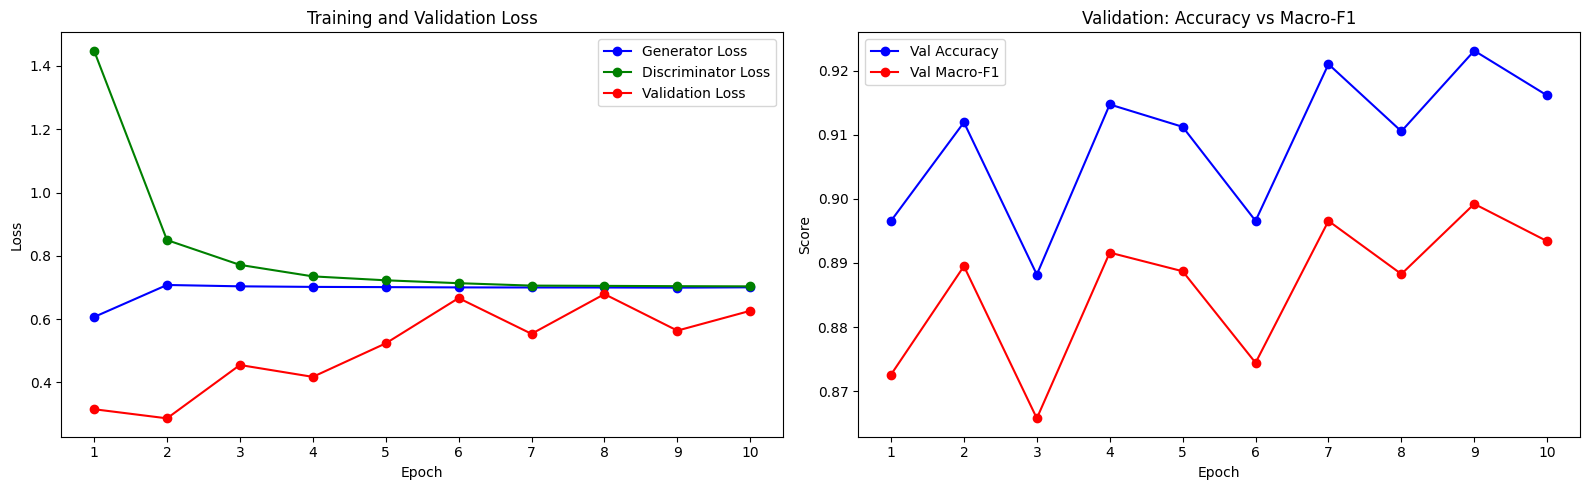

In [22]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
ax1.plot(df_stats['Training Loss generator'],     'b-o', label='Generator Loss')
ax1.plot(df_stats['Training Loss discriminator'], 'g-o', label='Discriminator Loss')
ax1.plot(df_stats['Valid. Loss'],                 'r-o', label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_xticks(df_stats.index)

# [CHANGED] Macro-F1 curve — plot alongside accuracy so you can see the difference.
# WHY: this shows concretely how accuracy and macro-F1 diverge under class imbalance.
ax2.plot(df_stats['Valid. Accur.'],   'b-o', label='Val Accuracy')
ax2.plot(df_stats['Valid. MacroF1'], 'r-o', label='Val Macro-F1')
ax2.set_title('Validation: Accuracy vs Macro-F1')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()
ax2.set_xticks(df_stats.index)

plt.tight_layout()
plt.show()

In [23]:
best_transformer = BertModel.from_pretrained(model_name)
best_transformer.resize_token_embeddings(len(tokenizer))
best_transformer.load_state_dict(torch.load(transformer_path))
best_transformer.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(31091, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [24]:
best_discriminator = Discriminator(
    input_size=hidden_size, hidden_sizes=hidden_levels_d,
    num_labels=len(label_list), dropout_rate=out_dropout_rate
)
best_discriminator.load_state_dict(torch.load(discriminator_path))
best_discriminator.to(device)

Discriminator(
  (input_dropout): Dropout(p=0.1, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=768, out_features=768, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.1, inplace=False)
  )
  (logit): Linear(in_features=768, out_features=4, bias=True)
  (softmax): Softmax(dim=-1)
)

In [25]:
def gan_bert_predict(transformer, discriminator, test_dataloader):
    transformer.eval()
    discriminator.eval()

    all_preds          = []
    all_labels_ids     = []
    all_filtered_logits = []

    for batch in test_dataloader:
        b_input_ids  = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels     = batch[2].to(device)

        with torch.no_grad():
            model_outputs  = transformer(b_input_ids, attention_mask=b_input_mask)
            hidden_states  = model_outputs[-1]
            _, logits, probs = discriminator(hidden_states)
            filtered_logits  = logits[:, 0:-1]

        _, preds = torch.max(filtered_logits, 1)
        all_preds           += preds.detach().cpu()
        all_labels_ids      += b_labels.detach().cpu()
        all_filtered_logits += filtered_logits.detach().cpu()

    all_preds           = torch.stack(all_preds).numpy()
    all_labels_ids      = torch.stack(all_labels_ids).numpy()
    all_filtered_logits = torch.stack(all_filtered_logits).numpy()

    return all_labels_ids, all_preds, all_filtered_logits

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_true, y_pred, probs = gan_bert_predict(best_transformer, best_discriminator, eval_dataloader)

utilize_class_labels = ["NOTUTILIZE", "UTILIZE"]

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f'Accuracy:  {accuracy*100:.5f}%')
print(f'Precision: {precision*100:.5f}%')
print(f'Recall:    {recall*100:.5f}%')
print(f'F1 Score:  {f1*100:.5f}%')
print()
print(classification_report(y_true, y_pred, target_names=utilize_class_labels, zero_division=0, digits=3))

Accuracy:  92.46231%
Precision: 90.79731%
Recall:    89.18906%
F1 Score:  89.94975%

              precision    recall  f1-score   support

  NOTUTILIZE      0.940     0.959     0.950       591
     UTILIZE      0.876     0.824     0.849       205

    accuracy                          0.925       796
   macro avg      0.908     0.892     0.899       796
weighted avg      0.924     0.925     0.924       796



In [27]:
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

def evaluate_roc(probs, y_true):
    preds   = probs[:, 2]
    fpr, tpr, threshold = roc_curve(y_true, preds)
    roc_auc = auc(fpr, tpr)
    print(f'AUC: {roc_auc:.4f}')
    y_pred  = np.where(preds >= 0.5, 1, 0)
    accuracy = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {accuracy*100:.2f}%')
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label=f'AUC = {roc_auc:.2f}')
    plt.legend(loc='lower right')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlim([0, 1]); plt.ylim([0, 1])
    plt.ylabel('True Positive Rate'); plt.xlabel('False Positive Rate')
    plt.show()

# evaluate_roc(probs, y_true-1)

[[567  24]
 [ 36 169]]


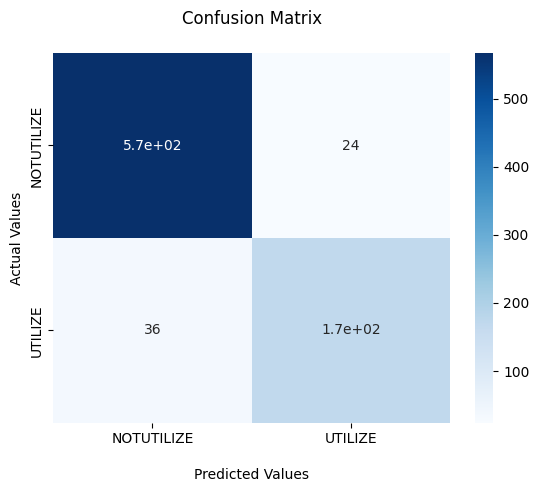

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_true, y_pred)
print(cf_matrix)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues')
ax.set_title('Confusion Matrix\n')
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(utilize_class_labels)
ax.yaxis.set_ticklabels(utilize_class_labels)
plt.show()

In [29]:
inv_encoding = {v: k for k, v in label_map.items()}
pred_label   = [inv_encoding[key] for key in y_pred]

In [30]:
def load_eval_dataset(fold=1, percentage=None):
    df = pd.read_csv(f'/content/drive/MyDrive/spin-off/final_dataset/fold_{fold}/10-fold_original_{percentage}/algocite_utilize_dataset_test_fold_{fold}.csv')
    df['CLEAN_CITATION_CONTEXT'] = df['CLEAN_CITATION_CONTEXT'].str.replace(r"=-=[\S\s]+-=-", "<cite>", regex=True)
    return df['CLEAN_CITATION_CONTEXT'].values, df['UTILIZE_LABELS'].values

X_test, y_test = load_eval_dataset(fold=fold, percentage=percentage)
df_test = pd.DataFrame({
    'CLEAN_CITATION_CONTEXT': X_test,
    'UTILIZE_LABELS':         y_test,
    'PRED_LABELS':            pred_label
})
df_test

,CLEAN_CITATION_CONTEXT,UTILIZE_LABELS,PRED_LABELS
0,their global optimisation procedure. note also...,NOTUTILIZE,NOTUTILIZE
1,clear which node s time shall be used as the r...,NOTUTILIZE,NOTUTILIZE
2,"in o( a z s b ( s b )), which is polynomial ti...",NOTUTILIZE,NOTUTILIZE
3,to temporal or resource constraints.s2.1.saspe...,UTILIZE,UTILIZE
4,nly used to track and synthesize faces in vide...,NOTUTILIZE,NOTUTILIZE
...,...,...,...
791,ocation are o( gamma n k delta 2 n gammak ) an...,NOTUTILIZE,NOTUTILIZE
792,"ch our work can be extended. we may ask, how c...",NOTUTILIZE,NOTUTILIZE
793,"s about sockets, remote procedure calls, data ...",NOTUTILIZE,NOTUTILIZE
794,there exists a path of qrds q r of a for which...,NOTUTILIZE,UTILIZE


In [31]:
import os
os.makedirs('/content/drive/MyDrive/cls_results', exist_ok=True)

df_test.to_csv(
    f'/content/drive/MyDrive/cls_results/GAN_SciBERT_improved_UTILIZE_{percentage}_Fold_{fold}.csv',
    index=False
)
print("Saved.")

Saved.
